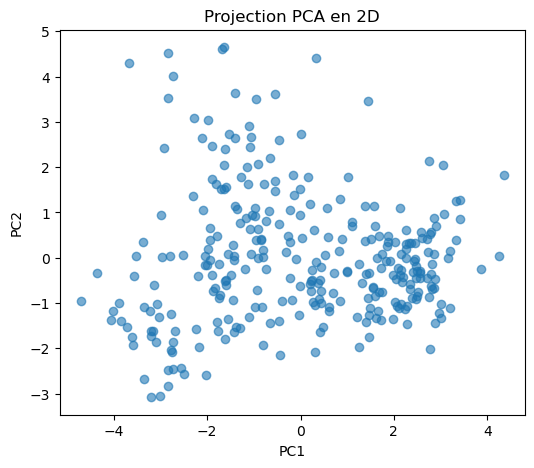

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("city_lifestyle_dataset.csv", sep=";") 

# On ne garde que les valeurs numériques
X = df.drop(columns=["label"], errors="ignore")
X = X.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.title("Projection PCA en 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

pd.DataFrame(X_pca, columns=["dim1","dim2"]).to_csv("pca_2d.csv", index=False)

# La projection PCA en 2D montre une structure non uniforme avec au moins trois 
# zones de densité distinctes. On observe un groupe principal centré autour de 
# PC1 environ à 2 et PC2 = 0, un second groupe plus diffus autour de PC1 = -2 et PC2 ≈ 1,
# et une poche plus compacte vers PC1 = -3 et PC2 = -2. 
# L’amplitude est plus forte sur l’axe PC1 (≈ -4.5 à 4.5) que sur PC2 (≈ -3 à 5), ce qui indique que la première
# composante capte la plus grande part de variance. La séparation reste partielle,
# avec un chevauchement central, ce qui veut dire que l'on a une structure latente 
# présente mais non strictement linéaire.